# **Optimizacion Combinatoria**
## **Tarea 7**: GRASP - 2D CSP
## **CIMAT** Mty
### *Gustavo Hernandez Angeles & Diego Paniagua Molina*
---

## **Librerias**

In [1]:
# ----------------- Librerias Necesarias -----------------

import copy                             # Para realizar copias profundas de objetos
import random                           # Para generacion de numeros aleatorios controlados
import matplotlib.pyplot as plt         # Para creacion de graficos
import matplotlib.patches as patches    # Para dibujar formas (rectangulos) en graficos
import matplotlib.cm as cm          # Para crear mapas de colores

import itertools
from dataclasses import dataclass, field          # Para deifinir estructuras de datos de manera compacta
from typing import List, Tuple, Optional    # Para anotaciones de tipos de datos

## **Estructuras de Datos**

In [2]:
# ----------------- Contendeores de Datos -----------------

@dataclass
class PieceType:
    """Metadatos de un tipo de pieza: dimensiones basicas,
    demanda total y si se permite rotar 90°."""
    id: int                     # Identificador unico del tipo de pieza
    w: int                      # Ancho original de la pieza
    h: int                      # Alto original de la pieza
    demand: int                 # Cantidad total requerida de este tipo de pieza
    rotatable: bool = False     # Indica si la pieza se puede rotar 90°
    instance_id: int = field(default_factory=itertools.count().__next__, init=False, repr=False)
    
    def area(self):
        """Calcula el área actual ocupada por esta pieza."""
        return self.w * self.h

@dataclass
class Piece:
    """Copia concreta de una pieza a colocar; almacena ademas
    coordenadas y estado de rotacion dentro de la lamina."""
    type_id: int                # Identificador del tipo de pieza
    w: int                      # Ancho actual de la pieza (podria cambiar si rota)
    h: int                      # Alto actual de la pieza (podria cambiar si rota)
    rotated: bool = False       # Estado de rotacion de la pieza
    x: int = 0                  # Coordenada horizontal (posicion x) de la pieza colocada
    y: int = 0                  # Coordenada vertical (posicion y) de la pieza colocada
    instance_id: int = field(default_factory=itertools.count().__next__, init=False, repr=False)

    def area(self):
        """Calcula el área actual ocupada por esta pieza."""
        return self.w * self.h

@dataclass
class EmptySpace:
    """Representa un rectangulo libre dentro de la lamina
    disponible para colocar proximas piezas."""
    x: int                      # Coordenada horizontal inicial del espacio
    y: int                      # Coordenada vertical inicial del espacio
    w: int                      # Ancho del espacio libre
    h: int                      # Alto del espacio libre

    def area(self):
        """Calcula el área disponible del espacio."""
        return self.w * self.h

@dataclass
class Solution:
    """Agrupa las piezas colocadas y no colocadas, asi como
    el desperdicio de area resultante."""
    placed: List[Piece]         # Lista de piezas exitosamente colocadas
    unplaced: List[Piece]       # Lista de piezas que no fueron colocadas
    waste_area: int             # Area total desperdiciada en la solucion obtenida

## **Implementacion GRASP**

In [ ]:
# ----------------- Implementacion GRASP  -----------------

class GRASP2DCSP:
    """Implementa el procedimiento GRASP completo:
    – constructivo (RCL-BLF)  
    – búsqueda local (swap + move)  
    Devuelve la mejor solución encontrada en max_iter iteraciones."""

    def __init__(self, sheet_size: Tuple[int, int], piece_types: List[PieceType],
                 alpha: float = 0.25, max_iter: int = 30, seed: Optional[int] = None):
        """Inicializa parámetros globales, lista de tipos de pieza,
        tamaño de la lámina y generador aleatorio."""

        self.B, self.H = sheet_size     # Dimensiones de la lamina
        self.types = piece_types        # Lista de tipos de pieza disponibles
        self.alpha = alpha              # Parametro alpha para construir la RCL
        self.max_iter = max_iter        # Numero maximo de iteraciones GRASP
        self.rng = random.Random(seed)  # Generador aleatorio

    def run(self):
        """Ejecuta constructivo + búsqueda local varias veces y
        conserva la mejor combinación (sol_mc, sol_bl)."""

        best_bl = None          # Mejor solucion tras busqueda local
        best_mc = None          # Solucion constructiva asociada

        for _ in range(self.max_iter):
            sol_mc = self.construct()            # Construye una solucion inicial
            sol_bl = self.local_search(sol_mc)   # Optimiza la solucion construida

            # Actualiza la mejor solucion encontrada
            if best_bl is None or sol_bl.waste_area < best_bl.waste_area:
                best_bl = sol_bl
                best_mc = sol_mc
        return best_mc, best_bl

    # ----------------- Constructor -----------------

    def construct(self):
        """Construye una solución factible usando RCL basada en área
        y la heurística Bottom-Left-Fill para colocar piezas."""

        spaces = [EmptySpace(0, 0, self.B, self.H)]      # Espacio inicial disponible
        candidates = self.expand_demand()                # Genera lista de piezas a colocar
        placed, unplaced = [], []                        # Inicializa listas de piezas colocadas y no colocadas

        while candidates:
            values = [p.area() for p in candidates]      # Areas de piezas candidatas
            g_max, g_min = max(values), min(values)      # Area maxima y minima

            # Umbral para formar la RCL (Lista Restringida de Candidatos)
            thresh = g_max - self.alpha * (g_max - g_min)
            rcl = [p for p, v in zip(candidates, values) if v >= thresh]    # Piezas en RCL
            chosen = self.rng.choice(rcl)       # Selecciona aleatoriamente una pieza de RCL

            pos = self.place_piece(chosen, spaces)      # Intenta colocar la pieza seleccionada
            if pos:
                chosen.x, chosen.y = pos            # Asigna posicion a la pieza    
                placed.append(chosen)               # Añade pieza a las colocadas
                self.split_space(chosen, spaces)    # Divide el espacio ocupado
                self.prune_spaces(spaces)           # Limpia espacios redundantes
            else:
                unplaced.append(chosen)             # Si no cabe, añade a piezas no colocadas

            candidates.remove(chosen)               # Elimina pieza elegida de candidatos

        waste = self.compute_waste(placed)          # Calcula area desperdiciada
        return Solution(placed, unplaced, waste)

    # ----------------- Bussqueda local (swap/move) -----------------

    def local_search(self, sol: Solution) -> Solution:
        """Mejora la solución con un vecindario que intercambia
        piezas colocadas con no colocadas, o recoloca una pieza en
        otro hueco, aplicando criterio best-improvement."""

        best = copy.deepcopy(sol)       # Copia la solucion inicial
        improvement = True              # Inicializa indicador de mejora encontrada

        while improvement:              
            improvement = False         # Restablece el indicador de mejora en cada iteracion        
            spaces = self._rebuild_spaces(best.placed)      # Reconstruye huecos disponibles

            IN  = sorted(best.placed,   key=lambda p: -p.area())    # Piezas colocadas ordenadas
            OUT = sorted(best.unplaced, key=lambda p: -p.area())    # Piezas no colocadas ordenadas

            # Vecindario swap: intercambia piezas colocadas con no colocadas
            for p in IN:
                freed = EmptySpace(p.x, p.y, p.w, p.h)      # Espacio liberado por pieza retirada
                
                for q in OUT:
                    if self._fits(q, freed):
                        new_sol = self._apply_swap(best, p, q, freed)   # Aplica intercambio (swap) entre piezas p y q
                        
                        if new_sol.waste_area < best.waste_area:
                            best = new_sol
                            improvement = True
                            break      # Interrumpe busqueda para reiniciar vecindario      
                if improvement:
                    break              # Sale del bucle externo si se ha encontrado mejora

            if improvement:
                continue               # Reinicia busqueda local desde el inicio tras una mejora

            # Vecindario move: intenta recolocar piezas
            for p in IN:
                freed = EmptySpace(p.x, p.y, p.w, p.h)      # Espacio liberado al retirar la pieza p
                temp_spaces = spaces + [freed]              # Combina espacios disponibles con el espacio recien liberado
                self.prune_spaces(temp_spaces)              # Elimina espacios redundantes

                # Recorre los espacios disponibles ordenados según la estrategia BLF (abajo-izquierda primero)
                for s in sorted(temp_spaces, key=lambda e: (e.y, e.x)):
                    if s.area() == freed.area():
                        continue                            # Ignora espacio si es el mismo que fue liberado por la pieza

                    # Verifica si la pieza p puede caber en el espacio seleccionado
                    if self._fits(p, s):
                        new_sol = self._apply_move(best, p, s)      # Aplica movimiento (move) para recolocar pieza p
                        
                        # Si la recolocación mejora la solucion actual, actualiza la solucion
                        if new_sol.waste_area < best.waste_area:
                            best = new_sol
                            improvement = True
                            break        # Interrumpe busqueda para reiniciar vecindario
                if improvement:
                    break                # Sale del bucle externo si se ha encontrado mejora

        return best                      # Devuelve la mejor solucion encontrada tras finalizar la busqueda local

    # ----------------- Auxiliares busqueda local -----------------

    def _rebuild_spaces(self, placed: List[Piece]) -> List[EmptySpace]:
        """Reconstruye todos los huecos libres a partir de la
        colocación actual (reutiliza split_space/prune_spaces)."""

        spaces: List[EmptySpace] = [EmptySpace(0, 0, self.B, self.H)]   # Inicializa el espacio libre 

        # Divide y limpia los espacios disponibles tras colocar cada pieza
        for p in placed:
            self.split_space(p, spaces)     # Divide los espacios libres tras colocar pieza p
            self.prune_spaces(spaces)       # Elimina espacios redundantes tras cada división

        return spaces       # Retorna lista actualizada de espacios disponibles

    def _fits(self, piece: Piece, space: EmptySpace) -> bool:
        """Chequea si la pieza cabe en el hueco, considerando
        rotación opcional."""

        # Chequea si la pieza cabe directamente sin rotar
        if piece.w <= space.w and piece.h <= space.h:
            return True
        
        # Chequea si la pieza puede rotarse y cabe rotada en el espacio
        if self.types[piece.type_id-1].rotatable and \
           piece.h <= space.w and piece.w <= space.h:
            return True
        return False        # La pieza no cabe en el espacio    

    def _apply_swap(self, sol: Solution, p: Piece, q: Piece,
                    freed: EmptySpace) -> Solution:
        """Devuelve solución nueva tras mover p a un hueco distinto
        preservando la factibilidad."""

        new_sol = copy.deepcopy(sol)

        try:
            # Encuentra la pieza en la copia por su ID único
            p_in_new_sol = next(z for z in new_sol.placed if z.instance_id == p.instance_id)
            new_sol.placed.remove(p_in_new_sol)
        except StopIteration:
            print(f"ADVERTENCIA: No se encontró p con instance_id {p.instance_id} en new_sol.placed durante swap.")
            return sol # Opcional: abortar si hay inconsistencia

        p_copy_for_unplaced = copy.deepcopy(p)
        new_sol.unplaced.append(p_copy_for_unplaced)

        q_copy = copy.deepcopy(q)
        # Verifica y aplica rotacion si la pieza no cabe directamente en el espacio liberado
        if not (q_copy.w <= freed.w and q_copy.h <= freed.h):
            q_copy.w, q_copy.h = q_copy.h, q_copy.w # Rota dimensiones
            q_copy.rotated = not q_copy.rotated # Actualiza estado de rotacion

        q_copy.x, q_copy.y = freed.x, freed.y # Coloca la pieza q en la posicion del espacio liberado
        new_sol.placed.append(q_copy)

        try:
            q_in_new_sol_unplaced = next(z for z in new_sol.unplaced if z.instance_id == q.instance_id)
            new_sol.unplaced.remove(q_in_new_sol_unplaced)
        except StopIteration:
            print(f"ADVERTENCIA: No se encontró q con instance_id {q.instance_id} en new_sol.unplaced durante swap.")
            return sol # Opcional: abortar si hay inconsistencia

        new_sol.waste_area = self.compute_waste(new_sol.placed)
        return new_sol

    def _apply_move(self, sol: Solution, p: Piece, target: EmptySpace) -> Solution:
        """Devuelve nueva solución tras mover p dentro de 'target'."""

        new_sol = copy.deepcopy(sol)        # Crea copia profunda de la solución original

        try:
            # Encuentra el índice de p en la copia por su ID único
            idx_moving = next(i for i, z in enumerate(new_sol.placed) if z.instance_id == p.instance_id)
            moving = new_sol.placed.pop(idx_moving)
        except StopIteration:
            print(f"ADVERTENCIA: No se encontró p con instance_id {p.instance_id} en new_sol.placed durante move.")
            return sol
        
        # Verifica y aplica rotacion si la pieza no cabe directamente en el nuevo espacio
        if not (moving.w <= target.w and moving.h <= target.h):
            moving.w, moving.h = moving.h, moving.w     # Rota dimensiones     
            moving.rotated = not moving.rotated         # Actualiza estado de rotacion

        moving.x, moving.y = target.x, target.y         # Coloca la pieza en la nueva posicion objetivo
        new_sol.placed.append(moving)                   # Añade pieza recolocada a la solución

        # Actualiza el area desperdiciada tras mover la pieza
        new_sol.waste_area = self.compute_waste(new_sol.placed)
        
        # Las piezas no colocadas permanecen sin cambios
        return new_sol

    # ----------------- Auxiliares constructivo -----------------

    def expand_demand(self):
        """Expande la demanda de cada tipo en copias individuales
        y mezcla el orden para diversificar la construcción."""

        lst = []         # Lista para almacenar todas las piezas individuales
        for t in self.types:
            for _ in range(t.demand):            
                lst.append(Piece(t.id, t.w, t.h))       # Agrega copias segun demanda
        self.rng.shuffle(lst)                           # Mezcla aleatoriamente la lista
        return lst                                      # Retorna lista mezclada

    def place_piece(self, piece: Piece, spaces: List[EmptySpace]):
        """Coloca una pieza en el primer hueco libre (BLF),
        probando rotación si está permitida."""

         # Ordena espacios disponibles segun coordenadas y, luego x 
        for s in sorted(spaces, key=lambda e: (e.y, e.x)):
            if piece.w <= s.w and piece.h <= s.h:
                return (s.x, s.y)        # Retorna posicion si pieza cabe sin rotacion
            
            # Chequea y aplica rotacion si es posible
            if self.types[piece.type_id-1].rotatable and piece.h <= s.w and piece.w <= s.h:
                piece.w, piece.h = piece.h, piece.w     # Rota dimensiones
                piece.rotated = not piece.rotated       # Actualiza estado de rotacion
                return (s.x, s.y)                       # Retorna posición después de rotacion
        return None                                     # Retorna None si no encuentra espacio adecuado

    def split_space(self, piece: Piece, spaces: List[EmptySpace]):
        """Divide el hueco ocupado en hasta dos sub-huecos
        (derecha y arriba) manteniendo la estrategia BLF."""

        new_spaces = []      # Lista temporal para nuevos espacios
        for s in spaces:
            # Si no hay solapamiento con pieza, conserva el espacio
            if not self.rect_overlap(piece.x, piece.y, piece.w, piece.h, s.x, s.y, s.w, s.h):
                new_spaces.append(s)
            else:
                # Crea nuevo espacio a la derecha de la pieza colocada
                if s.x + piece.w < s.x + s.w:
                    new_spaces.append(EmptySpace(s.x + piece.w, s.y, s.w - piece.w, piece.h))
                # Crea nuevo espacio encima de la pieza colocada
                if s.y + piece.h < s.y + s.h:
                    new_spaces.append(EmptySpace(s.x, s.y + piece.h, s.w, s.h - piece.h))
        spaces[:] = new_spaces      # Actualiza lista de espacios con nuevos sub-espacios

    def prune_spaces(self, spaces: List[EmptySpace]):
        """Elimina huecos redundantes o completamente contenidos
        dentro de otros, reduciendo el listado."""

        spaces[:] = [s for s in spaces if not any(self.rect_contains(t, s) for t in spaces if t is not s)]

    # ----------------- Utilidades geometricas -----------------
    def rect_overlap(self, x1, y1, w1, h1, x2, y2, w2, h2):
        """Prueba de solapamiento entre dos rectángulos."""
        return not (x1 + w1 <= x2 or x2 + w2 <= x1 or y1 + h1 <= y2 or y2 + h2 <= y1)

    def rect_contains(self, a: EmptySpace, b: EmptySpace):
        """Comprueba si un hueco está completamente contenido en otro."""

        return (a.x <= b.x and a.y <= b.y and a.x + a.w >= b.x + b.w and a.y + a.h >= b.y + b.h)

    def compute_waste(self, placed):
        """Calcula el área desperdiciada respecto a la lámina."""

        used = sum(p.area() for p in placed)      
        return self.B * self.H - used              

## **Instancias**

### Instancia 1

In [ ]:
sheet1 = (100, 100)  # Define las dimensiones de la lamina: (ancho, alto)

types1 = [
    PieceType(1, 30, 30, 5),                    # Tipo 1: pieza 30x30 con demanda de 4 unidades
    PieceType(2, 20, 40, 6, rotatable=True),    # Tipo 2: pieza 20x40 con demanda de 3 unidades, rotación permitida
    PieceType(3, 10, 10, 10)                    # Tipo 3: pieza 10x10 con demanda de 10 unidades
]

grasp1 = GRASP2DCSP(sheet1, types1, alpha=0.25, max_iter=30, seed=42)

# Ejecuta el algoritmo GRASP, obteniendo la solución constructiva (sol_mc) y la mejorada por búsqueda local (sol_bl)
sol_mc1, sol_bl1 = grasp1.run()

### Instancia 2

In [15]:
sheet2 = (127, 82)
types2 = [
    PieceType(1, 54, 30, 3),                    
    PieceType(2, 40, 20, 4, rotatable=True),    
    PieceType(3, 34, 30, 5),                    
    PieceType(4, 20, 11, 6, rotatable=True),    
]


grasp2 = GRASP2DCSP(sheet2, types2, alpha=0.3, max_iter=40, seed=99)

sol_mc2, sol_bl2 = grasp2.run()

### Instancia 3

In [ ]:
sheet3 = (180, 120)  

types3 = [
    PieceType(1, 40, 33, 7, rotatable=True),        
    PieceType(2, 24, 20, 15, rotatable=True),       
    PieceType(3, 15, 15, 15),                       
    PieceType(4, 13, 21, 25, rotatable=True),       
    PieceType(5, 6, 5, 40)                          
]

grasp3 = GRASP2DCSP(sheet3, types3, alpha=0.35, max_iter=50, seed=2025)


sol_mc3, sol_bl3 = grasp3.run()

## **Resultados**

In [13]:
def mostrar_resultado(sheet, sol_mc, sol_bl, types, title):
    """ Muestra los resultados de la solucion constructiva y la mejorada,
    incluyendo las coordenadas y dimensiones de las piezas colocadas,
    y el area desperdiciada. Adicionalmente, grafica la colocacion de las piezas
    en la lamina, mostrando la solucion mejorada."""
    # ------------------ Mostrar resultados ------------------
    
    print("Solución inicial:", [(p.type_id, p.x, p.y, p.w, p.h) for p in sol_mc.placed]) 
    print("Desperdicio =", sol_mc.waste_area)                                     

    requested = sum(t.demand for t in types) 
    placed = len(sol_mc.placed)              
    print("Piezas colocadas:", placed, "de", requested) 
    
    # Imprime la demanda y las piezas colocadas por tipo
    for t in types:
        print(f"Tipo {t.id}: {t.demand} piezas requeridas, {len([p for p in sol_mc.placed if p.type_id == t.id])} colocadas.")
    print("")

    print("Óptimo local =", [(p.type_id, p.x, p.y, p.w, p.h) for p in sol_bl.placed]) 
    print("Desperdicio =", sol_bl.waste_area)                                    
    requested = sum(t.demand for t in types)  
    placed = len(sol_bl.placed)              
    print("Piezas colocadas:", placed, "de", requested)
    
    for t in types:
        print(f"Tipo {t.id}: {t.demand} piezas requeridas, {len([p for p in sol_bl.placed if p.type_id == t.id])} colocadas.")  
    print("")
    # ------------------ Visualizar colocacion ------------------

    fig, ax = plt.subplots(figsize=(6,6))

    placed_type_ids = sorted(list(set(p.type_id for p in sol_bl.placed)))
    num_placed_types = len(placed_type_ids)

    colormap = cm.get_cmap('Set1', max(1, num_placed_types)) 
    color_map = {type_id: colormap(i / num_placed_types) if num_placed_types > 0 else colormap(0.5)
                for i, type_id in enumerate(placed_type_ids)}

    for p in sol_bl.placed:
        piece_color = color_map.get(p.type_id, (0.7, 0.7, 0.7))
        ax.add_patch(patches.Rectangle(
            (p.x, p.y), p.w, p.h,
            facecolor=piece_color, edgecolor='black', linewidth=0.5
        ))

    legend_handles = []
    for type_id in sorted(color_map.keys()):
        color = color_map[type_id]
        patch = patches.Patch(color=color, label=f"Tipo {type_id}")
        legend_handles.append(patch)

    ax.legend(handles=legend_handles, title="Tipos de Pieza", loc='upper left', bbox_to_anchor=(1.02, 0.5 + num_placed_types*.05), borderaxespad=0.)

    ax.set_xlim(0, sheet[0])
    ax.set_ylim(0, sheet[1])
    ax.set_aspect('equal')                                      
    ax.set_title(title)
    plt.savefig(f"./figures/solucion_{title}.pdf", bbox_inches='tight', dpi=300)
    plt.show()

-----Primera instancia-----

Solución inicial: [(1, 0, 0, 30, 30), (1, 30, 0, 30, 30), (1, 60, 0, 30, 30), (2, 0, 30, 20, 40), (2, 20, 30, 20, 40), (2, 40, 30, 20, 40), (2, 60, 30, 20, 40), (1, 0, 70, 30, 30), (2, 80, 30, 20, 40), (1, 30, 70, 30, 30), (2, 60, 70, 40, 20), (3, 90, 0, 10, 10), (3, 90, 10, 10, 10), (3, 90, 20, 10, 10), (3, 60, 90, 10, 10), (3, 70, 90, 10, 10), (3, 80, 90, 10, 10), (3, 90, 90, 10, 10)]
Desperdicio = 0
Piezas colocadas: 18 de 21
Tipo 1: 5 piezas requeridas, 5 colocadas.
Tipo 2: 6 piezas requeridas, 6 colocadas.
Tipo 3: 10 piezas requeridas, 7 colocadas.

Óptimo local = [(1, 0, 0, 30, 30), (1, 30, 0, 30, 30), (1, 60, 0, 30, 30), (2, 0, 30, 20, 40), (2, 20, 30, 20, 40), (2, 40, 30, 20, 40), (2, 60, 30, 20, 40), (1, 0, 70, 30, 30), (2, 80, 30, 20, 40), (1, 30, 70, 30, 30), (2, 60, 70, 40, 20), (3, 90, 0, 10, 10), (3, 90, 10, 10, 10), (3, 90, 20, 10, 10), (3, 60, 90, 10, 10), (3, 70, 90, 10, 10), (3, 80, 90, 10, 10), (3, 90, 90, 10, 10)]
Desperdicio = 0
Piezas 

C:\Users\Gus\AppData\Local\Temp\ipykernel_5544\1108781407.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Set1', max(1, num_placed_types))


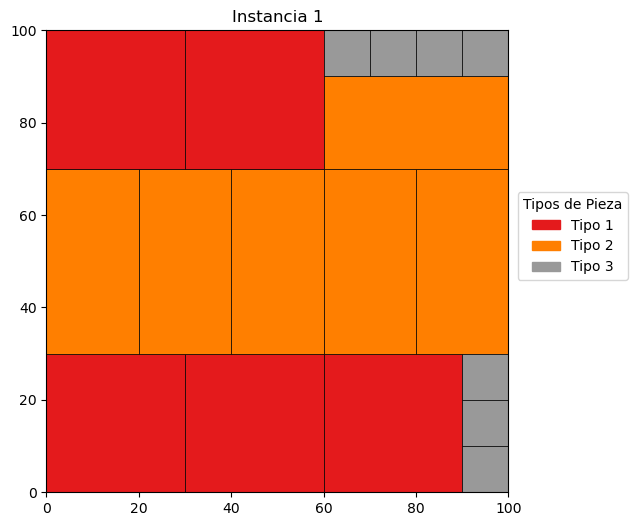




-----Segunda instancia-----

Solución inicial: [(1, 0, 0, 54, 30), (1, 54, 0, 54, 30), (1, 0, 30, 54, 30), (3, 54, 30, 34, 30), (3, 88, 30, 34, 30), (2, 0, 60, 40, 20), (2, 40, 60, 40, 20), (2, 80, 60, 40, 20), (4, 108, 0, 11, 20)]
Desperdicio = 894
Piezas colocadas: 9 de 18
Tipo 1: 3 piezas requeridas, 3 colocadas.
Tipo 2: 4 piezas requeridas, 3 colocadas.
Tipo 3: 5 piezas requeridas, 2 colocadas.
Tipo 4: 6 piezas requeridas, 1 colocadas.

Óptimo local = [(1, 0, 0, 54, 30), (1, 54, 0, 54, 30), (1, 0, 30, 54, 30), (3, 54, 30, 34, 30), (3, 88, 30, 34, 30), (2, 0, 60, 40, 20), (2, 40, 60, 40, 20), (2, 80, 60, 40, 20), (4, 108, 0, 11, 20)]
Desperdicio = 894
Piezas colocadas: 9 de 18
Tipo 1: 3 piezas requeridas, 3 colocadas.
Tipo 2: 4 piezas requeridas, 3 colocadas.
Tipo 3: 5 piezas requeridas, 2 colocadas.
Tipo 4: 6 piezas requeridas, 1 colocadas.



C:\Users\Gus\AppData\Local\Temp\ipykernel_5544\1108781407.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Set1', max(1, num_placed_types))


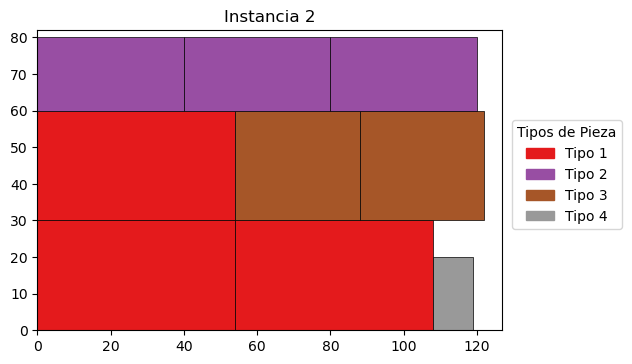




-----Tercera instancia-----

Solución inicial: [(1, 0, 0, 40, 33), (1, 40, 0, 40, 33), (1, 80, 0, 40, 33), (1, 120, 0, 40, 33), (1, 0, 33, 40, 33), (1, 40, 33, 40, 33), (1, 80, 33, 40, 33), (2, 160, 0, 20, 24), (2, 120, 33, 24, 20), (2, 144, 33, 24, 20), (2, 0, 66, 24, 20), (2, 24, 66, 24, 20), (2, 48, 66, 24, 20), (2, 72, 66, 24, 20), (2, 96, 66, 24, 20), (2, 120, 66, 24, 20), (2, 144, 66, 24, 20), (2, 0, 86, 24, 20), (2, 24, 86, 24, 20), (2, 48, 86, 24, 20), (2, 72, 86, 24, 20), (2, 96, 86, 24, 20), (3, 120, 86, 15, 15), (4, 120, 53, 21, 13), (4, 141, 53, 21, 13), (3, 135, 86, 15, 15), (3, 150, 86, 15, 15), (4, 0, 106, 21, 13), (3, 165, 86, 15, 15), (4, 21, 106, 21, 13), (4, 42, 106, 21, 13), (4, 63, 106, 21, 13), (4, 84, 106, 21, 13), (4, 105, 106, 21, 13), (4, 126, 106, 21, 13), (4, 147, 106, 21, 13), (5, 160, 24, 6, 5), (5, 166, 24, 6, 5), (5, 172, 24, 6, 5), (5, 168, 33, 6, 5), (5, 174, 33, 6, 5), (5, 168, 38, 6, 5), (5, 174, 38, 6, 5), (5, 168, 43, 6, 5), (5, 174, 43, 6, 5), 

C:\Users\Gus\AppData\Local\Temp\ipykernel_5544\1108781407.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('Set1', max(1, num_placed_types))


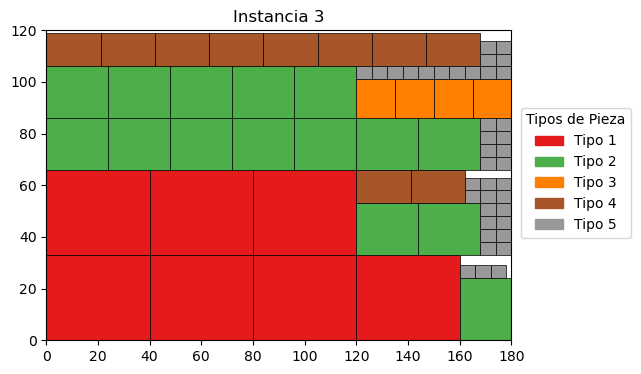

In [16]:
# Primera instancia
print("-----Primera instancia-----\n")
mostrar_resultado(sheet1, sol_mc1, sol_bl1, types1, title="Instancia 1") 
print("\n\n")


# Segunda instancia
print("-----Segunda instancia-----\n")
mostrar_resultado(sheet2, sol_mc2, sol_bl2, types2, title= "Instancia 2") 
print("\n\n")

# Tercera instancia
print("-----Tercera instancia-----\n")
mostrar_resultado(sheet3, sol_mc3, sol_bl3, types3, title = "Instancia 3")  
print("\n\n")